/tmp/ipykernel_688612/2894705794.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  log_history = torch.load(os.path.join(STORAGE_DIR, exp_dir, "training_metrics_hf.pth"))

[0.7979506254196167, 0.5956138968467712, 0.5532858967781067, 0.6365001797676086, 0.6118610501289368, 1.4778962135314941, 3.820739269256592, 2.5694894790649414, 1.6408703327178955, 1.1638849973678589, 1.2762459516525269, 1.5354591608047485, 1.5766960382461548, 1.9762920141220093, 1.2273861169815063, 1.5371439456939697, 1.6310830116271973, 1.8234310150146484, 1.735628604888916, 1.8694804906845093, 1.4123331308364868, 1.5602259635925293, 2.040118932723999, 1.3350824117660522, 1.3543320894241333, 1.5398424863815308, 1.0871978998184204, 1.3940385580062866, 1.5439971685409546, 1.1841351985931396, 1.186227798461914, 1.2409782409667969, 1.431460976600647, 1.1876460313796997, 1.3972241878509521, 1.5649449825286865, 1.4008524417877197, 1.1925265789031982, 1.4759920835494995, 1.6307225227355957, 1.3049652576446533, 1.8231920003890991, 1.4980517625808716, 1.7089221477508545, 1.7086111307144165, 1.6401557922363281, 1.847939133644104, 2.0790562629699707, 1.4425684213638306, 1.4369826316833496, 1.402

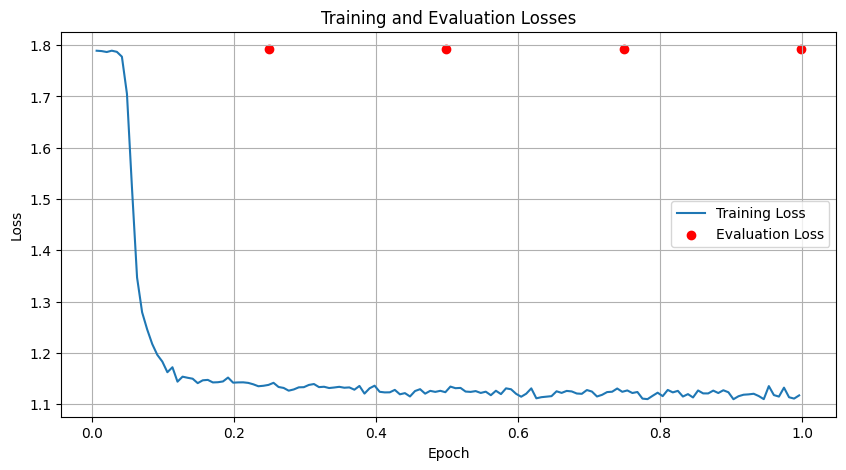

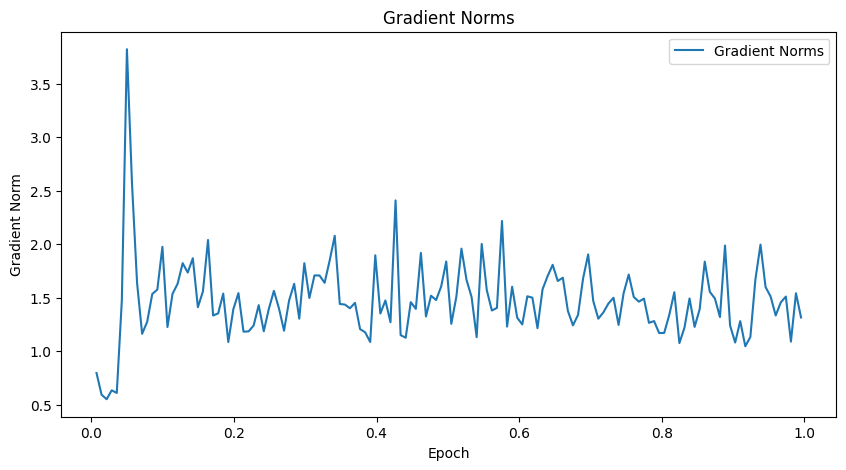

<Figure size 640x480 with 0 Axes>

In [4]:
import torch
import matplotlib.pyplot as plt

import os
STORAGE_DIR = os.getenv("STORAGE_DIR", "/media/discoexterno/leon")

def plot_training_metrics():

    # Load saved log history from the HF Trainer.
    # This file should contain a list of dictionaries with logged metrics.
    exp_dir = "ms_marco_passage/results/results_IR_ms_marco_unsloth_100k"
    log_history = torch.load(os.path.join(STORAGE_DIR, exp_dir, "training_metrics_hf.pth"))

    gradient_accumulation_steps = 4

    # Initialize lists to store metrics
    train_losses = []
    eval_losses = []
    grad_norms = []
    train_epochs = []
    eval_epochs = []

    # Iterate over each log entry and extract the metrics.
    for entry in log_history:
        # Check if a training loss is logged.
        if "loss" in entry:
            train_losses.append(entry["loss"] / gradient_accumulation_steps)
            train_epochs.append(entry["epoch"])
        # Check if an evaluation loss is logged.
        if "eval_loss" in entry:
            eval_losses.append(entry["eval_loss"])
            eval_epochs.append(entry["epoch"])
        # Check if a gradient norm is logged.
        if "grad_norm" in entry:
            grad_norms.append(entry["grad_norm"])

    print(grad_norms)
        
    # Plot training losses and evaluation losses in one plot.
    plt.figure(figsize=(10, 5))
    plt.plot(train_epochs, train_losses, label="Training Loss")
    # plot eval loss with dots scatter
    plt.scatter(eval_epochs, eval_losses, label="Evaluation Loss", color="red")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Evaluation Losses")
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(STORAGE_DIR, exp_dir, "training_eval_losses.png"))

    # Plot gradient norms in a separate plot.
    plt.figure(figsize=(10, 5))
    plt.plot(train_epochs, grad_norms, label="Gradient Norms")
    plt.xlabel("Epoch")
    plt.ylabel("Gradient Norm")
    plt.title("Gradient Norms")
    plt.legend()
    plt.show()
    plt.savefig(os.path.join(STORAGE_DIR, exp_dir, "grad_norms.png"))


if __name__ == "__main__":
    plot_training_metrics()